In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/heart-attack-prediction/data.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         294 non-null    int64  
 1   sex         294 non-null    int64  
 2   cp          294 non-null    int64  
 3   trestbps    294 non-null    object 
 4   chol        294 non-null    object 
 5   fbs         294 non-null    object 
 6   restecg     294 non-null    object 
 7   thalach     294 non-null    object 
 8   exang       294 non-null    object 
 9   oldpeak     294 non-null    float64
 10  slope       294 non-null    object 
 11  ca          294 non-null    object 
 12  thal        294 non-null    object 
 13  num         294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,294.0,47.826531,7.811812,28.0,42.0,49.0,54.0,66.0
sex,294.0,0.724490,0.447533,0.0,0.0,1.0,1.0,1.0
cp,294.0,2.982993,0.965117,1.0,2.0,3.0,4.0,4.0
oldpeak,294.0,0.586054,0.908648,0.0,0.0,0.0,1.0,5.0
num,294.0,0.360544,0.480977,0.0,0.0,0.0,1.0,1.0


In [7]:
df[df == '?'] = np.nan

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


<Axes: >

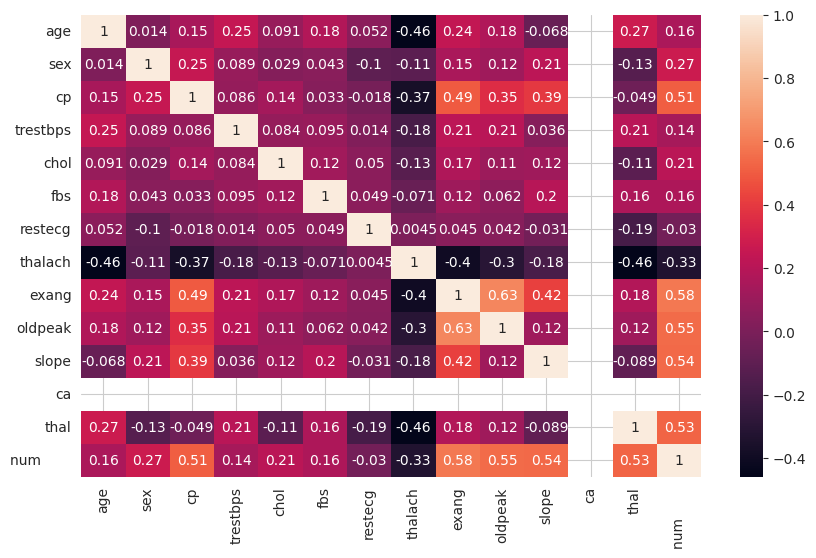

In [10]:
sns.heatmap(df.corr(), annot=True)

In [11]:
df.duplicated().sum()

1

In [12]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num       '],
      dtype='object')

In [13]:
df.rename(columns={'num       ': 'attack'}, inplace=True)

In [14]:
df.replace('?', np.nan, inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,attack
0,28,1,2,130,132,0,2,185,0,0.0,NaN,NaN,NaN,0
1,29,1,2,120,243,0,0,160,0,0.0,NaN,NaN,NaN,0
2,29,1,2,140,NaN,0,0,170,0,0.0,NaN,NaN,NaN,0
3,30,0,1,170,237,0,1,170,0,0.0,NaN,NaN,6,0
4,31,0,2,100,219,0,1,150,0,0.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,NaN,NaN,NaN,1
290,54,0,3,130,294,0,1,100,1,0.0,2,NaN,NaN,1
291,56,1,4,155,342,1,0,150,1,3.0,2,NaN,NaN,1
292,58,0,2,180,393,0,0,110,1,1.0,2,NaN,7,1


In [15]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps     object
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
attack        int64
dtype: object

In [16]:
df = df.astype({
    'trestbps': 'float64',
    'chol': 'float64',
    'fbs': 'float64',
    'restecg': 'float64',
    'thalach': 'float64',
    'exang': 'float64',
    'slope': 'float64',
    'thal': 'float64'
})

In [17]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,attack
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0


In [18]:
df.age.isnull().sum()

0

/tmp/ipykernel_37/3493913797.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(attack_data.age, rug=True, color='red')
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', Tru

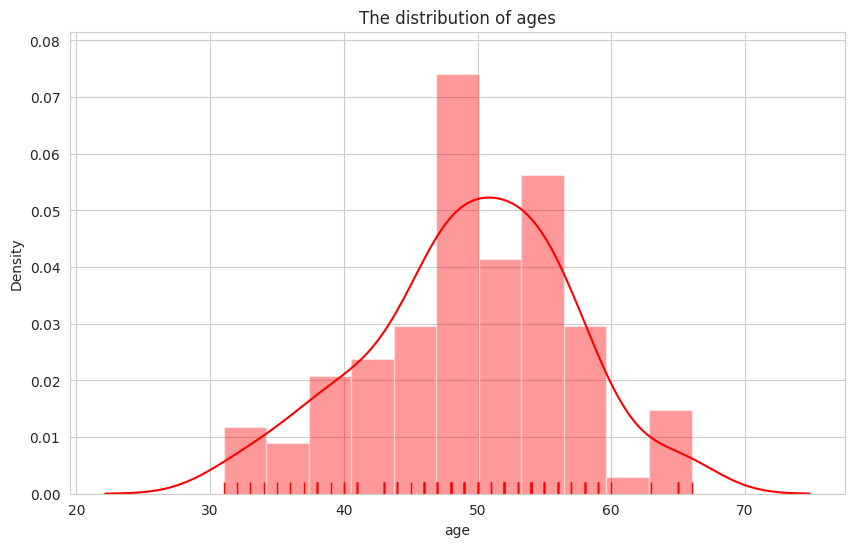

In [19]:
attack_data = df[df.attack==1]

ax = sns.distplot(attack_data.age, rug=True, color='red')
plt.title("The distribution of ages")
plt.show()

/tmp/ipykernel_37/3120533001.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df.attack==1], x='age', hue='attack', shade=True, ax=ax1, color='blue', alpha=1)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will ne

<Axes: title={'center': 'Age & Heart attack relation'}, xlabel='age', ylabel='Density'>

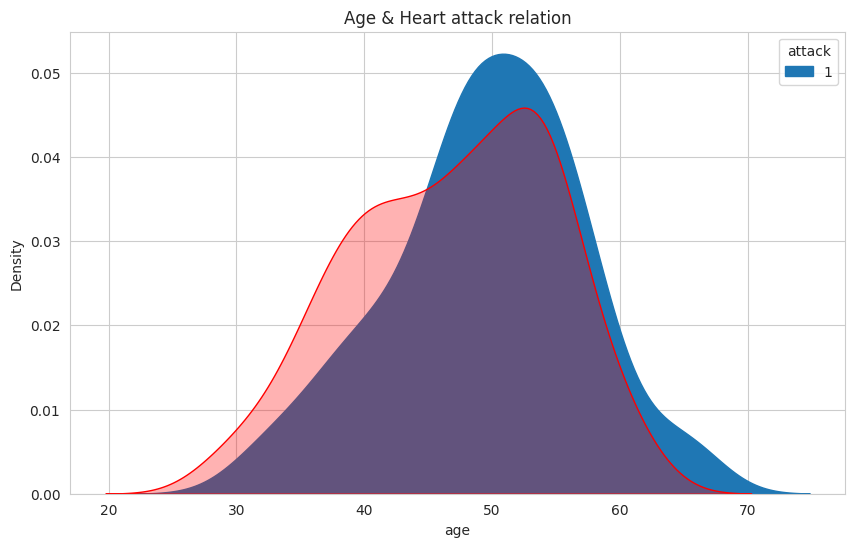

In [22]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(1,1,1)
plt.title('Age & Heart attack relation')
sns.kdeplot(data=df[df.attack==1], x='age', hue='attack', shade=True, ax=ax1, color='blue', alpha=1)
sns.kdeplot(data=df[df.attack==0], x='age', shade=True, ax=ax1, color='red', alpha=0.3)

In [23]:
df.sex.isnull().sum()

0

In [25]:
df.sex

0      1
1      1
2      1
3      0
4      0
      ..
289    1
290    0
291    1
292    0
293    1
Name: sex, Length: 294, dtype: int64

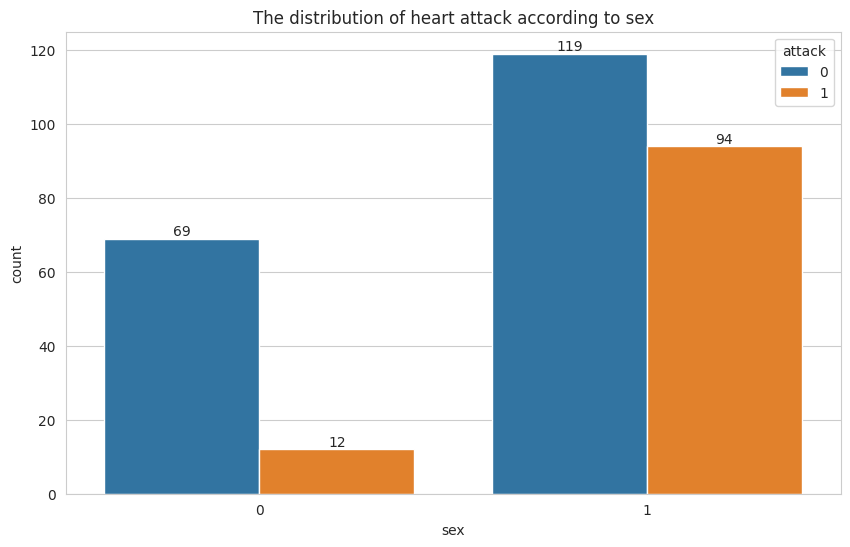

In [31]:
ax= sns.countplot(data=df, x='sex', hue='attack')
plt.title('The distribution of heart attack according to sex')
for p in ax.containers:
    ax.bar_label(p)

In [32]:
df.groupby('sex').attack.apply(lambda x: x.sum()/x.size * 100).sort_values(ascending=False)

sex
1    44.131455
0    14.814815
Name: attack, dtype: float64

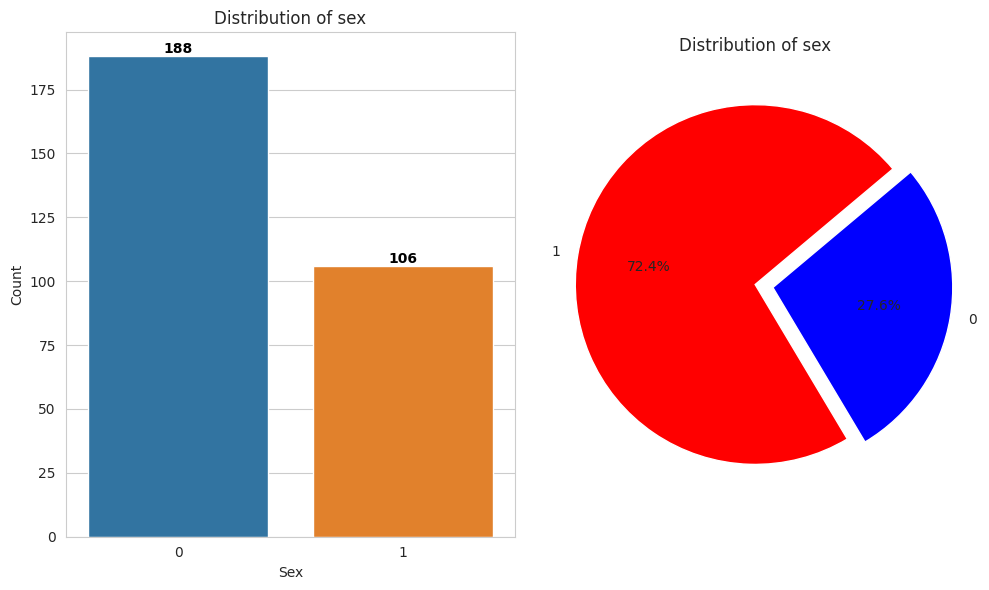

In [37]:
plt.subplot(1,2,1)
ax = sns.countplot(x='attack', data=df)
plt.title('Distribution of sex')
plt.xlabel('Sex')
plt.ylabel('Count')
ax.bar_label(ax.containers[0], fontsize=10, color='black', fontweight='bold')
plt.subplot(1,2,2)
plt.pie(df.sex.value_counts(), labels= df.sex.value_counts().index, autopct='%1.1f%%', startangle=40, explode=(0, 0.1), colors=['red', 'blue'])
plt.title('Distribution of sex')
plt.tight_layout()
plt.show()

In [39]:
df.trestbps.isnull().sum()

1

In [40]:
df.trestbps.value_counts(dropna=False)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


trestbps
120.0    65
130.0    54
140.0    50
150.0    23
110.0    21
160.0    20
125.0     8
180.0     6
100.0     6
145.0     5
170.0     5
135.0     5
112.0     3
115.0     2
124.0     2
118.0     2
122.0     2
105.0     1
92.0      1
128.0     1
136.0     1
138.0     1
200.0     1
106.0     1
108.0     1
113.0     1
98.0      1
NaN       1
132.0     1
142.0     1
190.0     1
155.0     1
Name: count, dtype: int64

In [41]:
trestbps_mean = df['trestbps'].mean()
print(trestbps_mean)

132.5836177474403


In [42]:
df.trestbps.fillna(trestbps_mean, inplace=True)

In [44]:
df.trestbps.isnull().sum()

0

In [45]:
df.chol.isnull().sum()

23

In [46]:
df.chol.value_counts(dropna=False).sort_values()

chol
466.0     1
355.0     1
518.0     1
329.0     1
285.0     1
         ..
216.0     4
230.0     5
246.0     5
275.0     5
NaN      23
Name: count, Length: 154, dtype: int64

In [47]:
chol_mean = df['chol'].mean()
chol_mean

250.84870848708488

In [48]:
df.chol.fillna(chol_mean, inplace=True)

/tmp/ipykernel_37/785597170.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.chol.fillna(chol_mean, inplace=True)


In [49]:
df.chol.isnull().sum()

0